# Z-Score Strategy

The Z-Score strategy is described in *Algorithmic Trading* by *Ernest P. Chan*. The strategy uses the Z-Score computed from a moving average and moving standard deviation with window equal to the half-life of mean reversion, namely,

$
\begin{align}
Z = \frac{y - \text{moving\_avg}(y, \text{halflife})}{\text{moving\_std}(y, \text{halflife})}
\end{align}
\tag{1}
$

The strategy involves holding a position equal to a multiple of the negative of the Z-Score. If it is negative a long position is held. For this case the the current price is below the mean value. If it is positive two options are available and investigated. In the first no position is held and in the second a short position is held that is a multiple of the Z-Score. For this case the price is above the mean.</br>

The aim of the strategy is to reduce the risk of holding a relatively large position when the mean reverts. The strategy holds a larger long or short position the further the current price is from the mean value and as the price approaches the mean the position is reduced.</br>

The asset analyzed is the USD/CAD exchange rate, CAD=X.

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import read_csv
from datetime import datetime

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison
from lib.data import stats, ou
from lib.utils import extract_date_range
from lib import trading

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [27]:
def read_backtrader_data(filename):
    data = read_csv(filename, index_col=0, parse_dates=["datetime"], date_format='%Y-%m-%d %H:%M:%S.%f')
    data.fillna(0.0, inplace=True)
    return data

def exchange_rate_plot(data, date):
    title = 'USD.CAD Exchange Rate'
    mean = numpy.full(len(data), numpy.mean(data))
    comparison([data, mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)


## CAD=X

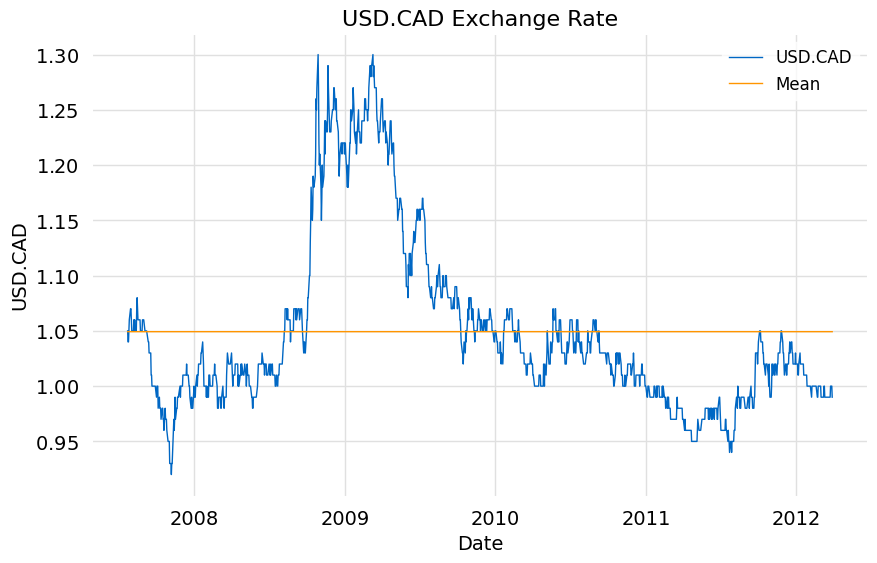

In [29]:
df = read_backtrader_data(os.path.abspath('../../../apps/output/mean-reversion-timeseries-CAD=X.csv'))
close = df.close.to_numpy()
date = df.datetime.to_numpy()
exchange_rate_plot(close, date)

## Strategy Exit Position on Positive Z-Score